In [1]:
import pandas as pd
import requests
print("set up working")
import matplotlib.pyplot as plt

set up working


In [2]:
price_url = "https://api.energy-charts.info/price"

price_params = {
    "country": "de",
    "start": "2026-01-01",
    "end": "2026-09-13"
}

price_response = requests.get(price_url, params=price_params)



In [3]:
print(price_response.status_code)

price_data = price_response.json()

print(price_data.keys())


200
dict_keys(['license_info', 'unix_seconds', 'price', 'unit', 'deprecated'])


In [5]:
price_df_timestamp = pd.to_datetime(
    price_data["unix_seconds"], unit="s", utc=True
).tz_convert("Europe/Berlin")

In [6]:
price_df = pd.DataFrame({
    "timestamp": price_df_timestamp ,
    "price": price_data["price"]
})

In [7]:
print(price_df.head())
print(price_df.shape)

                  timestamp  price
0 2026-01-01 00:00:00+01:00  63.64
1 2026-01-01 00:15:00+01:00  61.48
2 2026-01-01 00:30:00+01:00  58.00
3 2026-01-01 00:45:00+01:00  49.99
4 2026-01-01 01:00:00+01:00  60.01
(24572, 2)


In [8]:
local_diff = price_df["timestamp"].dt.tz_localize(None).diff()
print(local_diff.value_counts())

timestamp
0 days 00:15:00    24570
0 days 01:15:00        1
Name: count, dtype: int64


#### Data-quality note: daylight-saving time

The dataset uses Europe/Berlin local time. During the daylight-saving transition, four expected 15-minute local timestamps do not occur. This produces one 1-hour-15-minute gap in the naive local-time sequence.

This is a calendar/time-zone effect, not ordinary missing data, so the observations were not imputed or removed.

In [9]:
url = "https://api.energy-charts.info/v2/public_power"

params = {
    "country": "de",
    "start": "2026-01-01",
    "end": "2026-09-13"
}

power_response = requests.get(url, params=params)
power_data = power_response.json()

print(power_response.status_code)
print(power_data.keys())

200
dict_keys(['schema_version', 'endpoint', 'country', 'bidding_zone', 'timezone', 'resolution', 'interval_minutes', 'unit', 'generated_at', 'available_from', 'available_until', 'series', 'data', 'attributes', 'license', 'deprecated'])


In [10]:

print(power_data["series"])
print(power_data["data"][0])

[{'id': 'hydro_pumped_storage_consumption', 'name': 'Hydro pumped storage consumption'}, {'id': 'cross_border_electricity_trading', 'name': 'Cross border electricity trading'}, {'id': 'hydro_run_of_river', 'name': 'Hydro Run-of-River'}, {'id': 'biomass', 'name': 'Biomass'}, {'id': 'fossil_brown_coal_lignite', 'name': 'Fossil brown coal / lignite'}, {'id': 'fossil_hard_coal', 'name': 'Fossil hard coal'}, {'id': 'fossil_oil', 'name': 'Fossil oil'}, {'id': 'fossil_coal_derived_gas', 'name': 'Fossil coal-derived gas'}, {'id': 'fossil_gas', 'name': 'Fossil gas'}, {'id': 'geothermal', 'name': 'Geothermal'}, {'id': 'hydro_water_reservoir', 'name': 'Hydro water reservoir'}, {'id': 'hydro_pumped_storage', 'name': 'Hydro pumped storage'}, {'id': 'others', 'name': 'Others'}, {'id': 'waste', 'name': 'Waste'}, {'id': 'wind_offshore', 'name': 'Wind offshore'}, {'id': 'wind_onshore', 'name': 'Wind onshore'}, {'id': 'solar', 'name': 'Solar'}, {'id': 'load', 'name': 'Load'}, {'id': 'residual_load', 'na

In [11]:
rows = []

for row in power_data["data"]:
    rows.append({
        "timestamp": row["timestamp"],
        "load": row["values"].get("load"),
        "wind_onshore": row["values"].get("wind_onshore"),
        "solar": row["values"].get("solar")
    })

power_df = pd.DataFrame(rows)

In [12]:
power_df["timestamp"] = pd.to_datetime(
    power_df["timestamp"],
    utc=True
).dt.tz_convert("Europe/Berlin")

In [13]:
print(power_df["timestamp"].min(), power_df["timestamp"].max())
print(price_df["timestamp"].min(), price_df["timestamp"].max())

2026-01-01 00:00:00+01:00 2026-09-13 23:45:00+02:00
2026-01-01 00:00:00+01:00 2026-09-13 23:45:00+02:00


In [14]:
print(power_df.head())
print(power_df.shape)

                  timestamp     load  wind_onshore  solar
0 2026-01-01 00:00:00+01:00  46427.4       31462.6    0.0
1 2026-01-01 00:15:00+01:00  46085.1       31849.2    0.0
2 2026-01-01 00:30:00+01:00  46038.6       32711.4    0.0
3 2026-01-01 00:45:00+01:00  45940.4       33195.1    0.0
4 2026-01-01 01:00:00+01:00  45656.0       33481.0    0.0
(24572, 4)


In [15]:
print(power_df["timestamp"].equals(price_df["timestamp"]))

True


In [16]:
print(power_df["timestamp"].dtype)
print(price_df["timestamp"].dtype)

datetime64[ns, Europe/Berlin]
datetime64[ns, Europe/Berlin]


In [17]:
merged_df = power_df.merge(price_df, on="timestamp", how="inner")

print(merged_df.head())
print(merged_df.shape)

                  timestamp     load  wind_onshore  solar  price
0 2026-01-01 00:00:00+01:00  46427.4       31462.6    0.0  63.64
1 2026-01-01 00:15:00+01:00  46085.1       31849.2    0.0  61.48
2 2026-01-01 00:30:00+01:00  46038.6       32711.4    0.0  58.00
3 2026-01-01 00:45:00+01:00  45940.4       33195.1    0.0  49.99
4 2026-01-01 01:00:00+01:00  45656.0       33481.0    0.0  60.01
(24572, 5)


In [18]:
print(merged_df.isna().sum())

timestamp       0
load            0
wind_onshore    0
solar           0
price           0
dtype: int64


In [19]:
print(merged_df["timestamp"].duplicated().sum())

0


In [20]:
print(merged_df.dtypes)

timestamp       datetime64[ns, Europe/Berlin]
load                                  float64
wind_onshore                          float64
solar                                 float64
price                                 float64
dtype: object


In [21]:
merged_df.describe()

,load,wind_onshore,solar,price
count,24572.000000,24572.000000,24572.000000,24572.000000
mean,52964.910667,11837.663804,11622.087213,104.995103
std,9175.271446,8739.478519,15842.673407,64.545605
min,32445.500000,63.900000,0.000000,-499.990000
25%,45494.100000,4911.750000,0.000000,80.527500
50%,53036.050000,9871.300000,1313.400000,110.685000
75%,58826.775000,16854.750000,22058.100000,140.815000
max,78372.600000,47300.000000,58507.000000,747.100000


In [ ]:
print((merged_df["price"] < 0).sum())

1784


##### Data Quality Notes
- No missing values were found in the merged dataset.
- No duplicate timestamps were found.
- The dataset uses Europe/Berlin local time and contains one daylight-saving transition, producing a 1-hour-15-minute gap in the naive local-time sequence. This was treated as a timezone/calendar effect rather than imputed missing data.
- Negative electricity prices were retained because they are valid market observations.

## EDA


In [24]:
merged_df[["load", "wind_onshore", "solar", "price"]].describe()

,load,wind_onshore,solar,price
count,24572.000000,24572.000000,24572.000000,24572.000000
mean,52964.910667,11837.663804,11622.087213,104.995103
std,9175.271446,8739.478519,15842.673407,64.545605
min,32445.500000,63.900000,0.000000,-499.990000
25%,45494.100000,4911.750000,0.000000,80.527500
50%,53036.050000,9871.300000,1313.400000,110.685000
75%,58826.775000,16854.750000,22058.100000,140.815000
max,78372.600000,47300.000000,58507.000000,747.100000


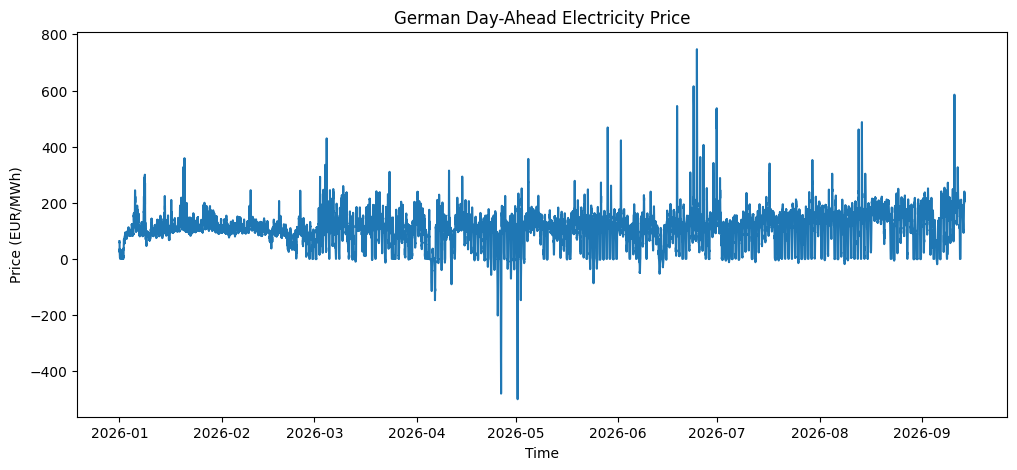

In [25]:
plt.figure(figsize=(12, 5))
plt.plot(merged_df["timestamp"], merged_df["price"])
plt.xlabel("Time")
plt.ylabel("Price (EUR/MWh)")
plt.title("German Day-Ahead Electricity Price")
plt.show()

In [26]:
merged_df[["load", "wind_onshore", "solar", "price"]].corr()

,load,wind_onshore,solar,price
load,1.000000,0.141104,0.103184,0.108615
wind_onshore,0.141104,1.000000,-0.294682,-0.229890
solar,0.103184,-0.294682,1.000000,-0.585808
price,0.108615,-0.229890,-0.585808,1.000000


In [27]:
merged_df["renewable_generation"] = (
    merged_df["wind_onshore"] + merged_df["solar"]
)

print(
    merged_df[["renewable_generation", "load", "price"]].corr()
)

                      renewable_generation      load     price
renewable_generation              1.000000  0.182936 -0.720157
load                              0.182936  1.000000  0.108615
price                            -0.720157  0.108615  1.000000


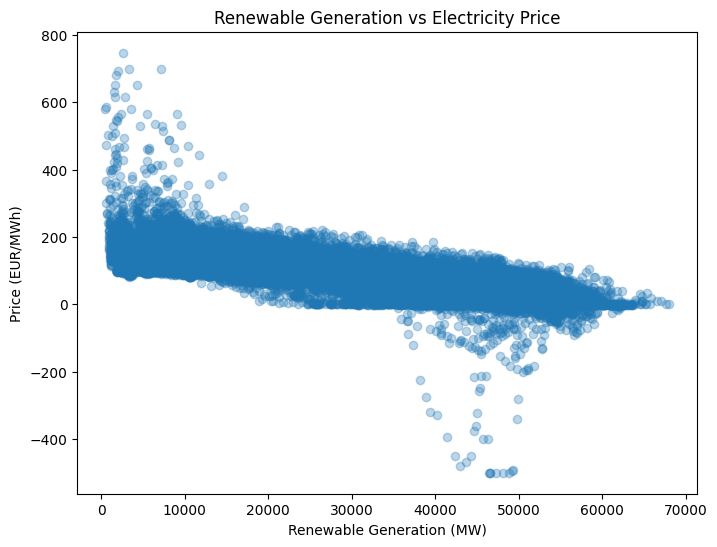

In [28]:
plt.figure(figsize=(8, 6))
plt.scatter(
    merged_df["renewable_generation"],
    merged_df["price"],
    alpha=0.3
)
plt.xlabel("Renewable Generation (MW)")
plt.ylabel("Price (EUR/MWh)")
plt.title("Renewable Generation vs Electricity Price")
plt.show()

In [31]:
merged_df["hour"] = merged_df["timestamp"].dt.hour
hourly_corr = (
    merged_df.groupby("hour")[["renewable_generation", "load", "price"]]
    .corr()
)

print(hourly_corr)

                           renewable_generation      load     price
hour                                                               
0    renewable_generation              1.000000  0.242775 -0.715165
     load                              0.242775  1.000000 -0.375899
     price                            -0.715165 -0.375899  1.000000
1    renewable_generation              1.000000  0.244449 -0.725575
     load                              0.244449  1.000000 -0.349356
...                                         ...       ...       ...
22   load                              0.260757  1.000000 -0.307928
     price                            -0.593254 -0.307928  1.000000
23   renewable_generation              1.000000  0.265307 -0.666173
     load                              0.265307  1.000000 -0.411312
     price                            -0.666173 -0.411312  1.000000

[72 rows x 3 columns]


In [33]:
hourly_price_corr = (
    hourly_corr.xs("price", level=1)[["renewable_generation", "load"]]
)

print(hourly_price_corr)

      renewable_generation      load
hour                                
0                -0.715165 -0.375899
1                -0.725575 -0.349356
2                -0.747154 -0.341109
3                -0.762641 -0.335934
4                -0.767529 -0.322010
5                -0.734277 -0.190457
6                -0.662942  0.101421
7                -0.610469  0.298373
8                -0.609388  0.438781
9                -0.641391  0.576895
10               -0.673570  0.634381
11               -0.687464  0.673360
12               -0.638631  0.667519
13               -0.567562  0.643155
14               -0.582748  0.647820
15               -0.670359  0.680865
16               -0.721605  0.636854
17               -0.722274  0.511905
18               -0.712480  0.233082
19               -0.567700 -0.076226
20               -0.558668 -0.180026
21               -0.563858 -0.210785
22               -0.593254 -0.307928
23               -0.666173 -0.411312


##### EDA Findings

- Renewable generation showed a strong negative linear association with day-ahead electricity price (r = -0.72).
- Overall load-price correlation was weakly positive (r = 0.11).
- The load-price relationship varied substantially by hour of day.
- The negative renewable-price association remained present when correlations were calculated separately by hour.
- Electricity price showed substantial volatility, including negative-price observations.

## Statistical Modeling

The target variable is electricity price. Predictor variables are load, wind generation, solar generation, and cyclical hour features.

A multiple linear regression model will be used first as a baseline to quantify the association between these predictors and electricity price.

In [34]:
import numpy as np

merged_df["hour_sin"] = np.sin(2 * np.pi * merged_df["hour"] / 24)
merged_df["hour_cos"] = np.cos(2 * np.pi * merged_df["hour"] / 24)

In [35]:
print(merged_df[["hour", "hour_sin", "hour_cos"]].head())

   hour  hour_sin  hour_cos
0     0  0.000000  1.000000
1     0  0.000000  1.000000
2     0  0.000000  1.000000
3     0  0.000000  1.000000
4     1  0.258819  0.965926


In [36]:
X = merged_df[
    ["load", "wind_onshore", "solar", "hour_sin", "hour_cos"]
]

y = merged_df["price"]

print(X.head())
print(y.head())

      load  wind_onshore  solar  hour_sin  hour_cos
0  46427.4       31462.6    0.0  0.000000  1.000000
1  46085.1       31849.2    0.0  0.000000  1.000000
2  46038.6       32711.4    0.0  0.000000  1.000000
3  45940.4       33195.1    0.0  0.000000  1.000000
4  45656.0       33481.0    0.0  0.258819  0.965926
0    63.64
1    61.48
2    58.00
3    49.99
4    60.01
Name: price, dtype: float64


In [37]:
split_index = int(len(X) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

(19657, 5) (4915, 5)
(19657,) (4915,)


In [39]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](5,)","[ 0. ,-0. ,-0. ,-5.4 , 8.87]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](5,)","['load','wind_onshore','solar','hour_sin','hour_cos']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,47.7
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,5
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(5)


In [40]:
print(model.coef_)
print(model.intercept_)

[ 2.32038877e-03 -3.61396543e-03 -2.75318677e-03 -5.40218500e+00
  8.87005994e+00]
47.69609847142801


In [41]:
y_pred = model.predict(X_test)

In [43]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 48.785571868885945
RMSE: 57.16713278611011
R²: 0.3109853197779444


In [44]:
baseline_pred = merged_df["price"].shift(1).loc[y_test.index]

baseline_mae = mean_absolute_error(y_test, baseline_pred)
baseline_rmse = mean_squared_error(y_test, baseline_pred) ** 0.5

print("Baseline MAE:", baseline_mae)
print("Baseline RMSE:", baseline_rmse)

Baseline MAE: 8.955511698880978
Baseline RMSE: 14.015047861187394


##### Baseline Comparison
A naive persistence baseline was evaluated by predicting each 15-minute price using the previous observed price.

The baseline substantially outperformed the initial linear regression model:

- Linear regression MAE: 48.78 EUR/MWh
- Baseline MAE: 8.96 EUR/MWh
- Linear regression RMSE: 57.16 EUR/MWh
- Baseline RMSE: 14.02 EUR/MWh

This indicates strong short-term price persistence and motivates the use of lagged price features in subsequent forecasting models.

In [45]:
merged_df["price_lag_1"] = merged_df["price"].shift(1)

In [46]:
print(merged_df[["timestamp", "price", "price_lag_1"]].head())

                  timestamp  price  price_lag_1
0 2026-01-01 00:00:00+01:00  63.64          NaN
1 2026-01-01 00:15:00+01:00  61.48        63.64
2 2026-01-01 00:30:00+01:00  58.00        61.48
3 2026-01-01 00:45:00+01:00  49.99        58.00
4 2026-01-01 01:00:00+01:00  60.01        49.99


In [47]:
model_df = merged_df.dropna(subset=["price_lag_1"]).copy()

In [48]:
X_lag = model_df[
    ["load", "wind_onshore", "solar", "hour_sin", "hour_cos", "price_lag_1"]
]

y_lag = model_df["price"]

split_index = int(len(X_lag) * 0.8)

X_train_lag = X_lag.iloc[:split_index]
X_test_lag = X_lag.iloc[split_index:]

y_train_lag = y_lag.iloc[:split_index]
y_test_lag = y_lag.iloc[split_index:]

print(X_train_lag.shape, X_test_lag.shape)

(19656, 6) (4915, 6)


In [49]:
lag_model = LinearRegression()
lag_model.fit(X_train_lag, y_train_lag)

y_pred_lag = lag_model.predict(X_test_lag)

lag_mae = mean_absolute_error(y_test_lag, y_pred_lag)
lag_rmse = mean_squared_error(y_test_lag, y_pred_lag) ** 0.5
lag_r2 = r2_score(y_test_lag, y_pred_lag)

print("Lag model MAE:", lag_mae)
print("Lag model RMSE:", lag_rmse)
print("Lag model R²:", lag_r2)

Lag model MAE: 8.738729767153334
Lag model RMSE: 13.524573936402877
Lag model R²: 0.9614359321285999


In [60]:
model_df = merged_df.copy()

model_df["price_lag_1"] = model_df["price"].shift(1)
model_df["price_lag_2"] = model_df["price"].shift(2)
model_df["price_lag_4"] = model_df["price"].shift(4)
model_df["price_lag_96"] = model_df["price"].shift(96)
model_df["price_lag_672"] = model_df["price"].shift(672)

model_df = model_df.dropna(
    subset=[
        "price_lag_1",
        "price_lag_2",
        "price_lag_4",
        "price_lag_96",
        "price_lag_672"
    ]
).copy()

print(model_df.shape)

(23900, 14)


In [61]:
X_lag672 = model_df[
    ["load", "wind_onshore", "solar",
     "hour_sin", "hour_cos",
     "price_lag_1", "price_lag_2", "price_lag_4",
     "price_lag_96", "price_lag_672"]
]

y_lag672 = model_df["price"]

split_index = int(len(X_lag672) * 0.8)

X_train_lag672 = X_lag672.iloc[:split_index]
X_test_lag672 = X_lag672.iloc[split_index:]

y_train_lag672 = y_lag672.iloc[:split_index]
y_test_lag672 = y_lag672.iloc[split_index:]

print(X_train_lag672.shape, X_test_lag672.shape)

(19120, 10) (4780, 10)


In [62]:
lag672_model = LinearRegression()
lag672_model.fit(X_train_lag672, y_train_lag672)

y_pred_lag672 = lag672_model.predict(X_test_lag672)

mae_lag672 = mean_absolute_error(y_test_lag672, y_pred_lag672)
rmse_lag672 = mean_squared_error(y_test_lag672, y_pred_lag672) ** 0.5
r2_lag672 = r2_score(y_test_lag672, y_pred_lag672)

print("MAE:", mae_lag672)
print("RMSE:", rmse_lag672)
print("R²:", r2_lag672)

MAE: 8.569033510485527
RMSE: 13.1821880264427
R²: 0.9631337175861957


In [65]:
common_df = merged_df.copy()

common_df["price_lag_1"] = common_df["price"].shift(1)
common_df["price_lag_2"] = common_df["price"].shift(2)
common_df["price_lag_4"] = common_df["price"].shift(4)
common_df["price_lag_96"] = common_df["price"].shift(96)
common_df["price_lag_672"] = common_df["price"].shift(672)

common_df = common_df.dropna(
    subset=[
        "price_lag_1",
        "price_lag_2",
        "price_lag_4",
        "price_lag_96",
        "price_lag_672"
    ]
).copy()

print(common_df.shape)

(23900, 14)


In [66]:
common_split = int(len(common_df) * 0.8)

common_train = common_df.iloc[:common_split]
common_test = common_df.iloc[common_split:]

print(common_train.shape)
print(common_test.shape)

(19120, 14)
(4780, 14)


In [67]:
features_1lag = [
    "load", "wind_onshore", "solar",
    "hour_sin", "hour_cos",
    "price_lag_1"
]

X_train_1lag = common_train[features_1lag]
X_test_1lag = common_test[features_1lag]

y_train_common = common_train["price"]
y_test_common = common_test["price"]

model_1lag = LinearRegression()
model_1lag.fit(X_train_1lag, y_train_common)

pred_1lag = model_1lag.predict(X_test_1lag)

mae_1lag = mean_absolute_error(y_test_common, pred_1lag)
rmse_1lag = mean_squared_error(y_test_common, pred_1lag) ** 0.5
r2_1lag = r2_score(y_test_common, pred_1lag)

print("MAE:", mae_1lag)
print("RMSE:", rmse_1lag)
print("R²:", r2_1lag)

MAE: 8.785192665228928
RMSE: 13.551834855437813
R²: 0.9610371655688794


In [68]:
features_24lag = features_1lag + ["price_lag_96"]

X_train_24lag = common_train[features_24lag]
X_test_24lag = common_test[features_24lag]

model_24lag = LinearRegression()
model_24lag.fit(X_train_24lag, y_train_common)

pred_24lag = model_24lag.predict(X_test_24lag)

mae_24lag = mean_absolute_error(y_test_common, pred_24lag)
rmse_24lag = mean_squared_error(y_test_common, pred_24lag) ** 0.5
r2_24lag = r2_score(y_test_common, pred_24lag)

print("MAE:", mae_24lag)
print("RMSE:", rmse_24lag)
print("R²:", r2_24lag)

MAE: 8.665194672916419
RMSE: 13.270036787937283
R²: 0.9626407116030882


In [69]:
features_3lag = features_24lag + ["price_lag_2", "price_lag_4"]

X_train_3lag = common_train[features_3lag]
X_test_3lag = common_test[features_3lag]

model_3lag = LinearRegression()
model_3lag.fit(X_train_3lag, y_train_common)

pred_3lag = model_3lag.predict(X_test_3lag)

mae_3lag = mean_absolute_error(y_test_common, pred_3lag)
rmse_3lag = mean_squared_error(y_test_common, pred_3lag) ** 0.5
r2_3lag = r2_score(y_test_common, pred_3lag)

print("MAE:", mae_3lag)
print("RMSE:", rmse_3lag)
print("R²:", r2_3lag)

MAE: 8.650977181940059
RMSE: 13.29693886214119
R²: 0.962489082618838


In [70]:
features_weekly = features_24lag + ["price_lag_672"]

X_train_weekly = common_train[features_weekly]
X_test_weekly = common_test[features_weekly]

model_weekly = LinearRegression()
model_weekly.fit(X_train_weekly, y_train_common)

pred_weekly = model_weekly.predict(X_test_weekly)

mae_weekly = mean_absolute_error(y_test_common, pred_weekly)
rmse_weekly = mean_squared_error(y_test_common, pred_weekly) ** 0.5
r2_weekly = r2_score(y_test_common, pred_weekly)

print("MAE:", mae_weekly)
print("RMSE:", rmse_weekly)
print("R²:", r2_weekly)

MAE: 8.575458001265558
RMSE: 13.147734015726014
R²: 0.9633261790122573


In [75]:
common_df = merged_df.copy()

common_df["price_lag_1"] = common_df["price"].shift(1)
common_df["price_lag_96"] = common_df["price"].shift(96)
common_df["price_lag_672"] = common_df["price"].shift(672)

common_df = common_df.dropna(
    subset=["price_lag_1", "price_lag_96", "price_lag_672"]
).copy()

day_dummies = pd.get_dummies(
    common_df["day_of_week"],
    prefix="day",
    drop_first=True,
    dtype=int
)

common_df = pd.concat([common_df, day_dummies], axis=1)

print(common_df.shape)

(23900, 19)


In [76]:
common_split = int(len(common_df) * 0.8)

common_train = common_df.iloc[:common_split]
common_test = common_df.iloc[common_split:]

y_train_common = common_train["price"]
y_test_common = common_test["price"]

features_weekday = (
    features_weekly
    + ["day_1", "day_2", "day_3", "day_4", "day_5", "day_6"]
)

X_train_weekday = common_train[features_weekday]
X_test_weekday = common_test[features_weekday]

print(X_train_weekday.shape, X_test_weekday.shape)

(19120, 14) (4780, 14)


In [77]:
model_weekday = LinearRegression()
model_weekday.fit(X_train_weekday, y_train_common)

pred_weekday = model_weekday.predict(X_test_weekday)

mae_weekday = mean_absolute_error(y_test_common, pred_weekday)
rmse_weekday = mean_squared_error(y_test_common, pred_weekday) ** 0.5
r2_weekday = r2_score(y_test_common, pred_weekday)

print("MAE:", mae_weekday)
print("RMSE:", rmse_weekday)
print("R²:", r2_weekday)

MAE: 8.383076708121616
RMSE: 12.954905495389609
R²: 0.9643940284812833


In [78]:
merged_df["month"] = merged_df["timestamp"].dt.month

In [ ]:
common_df = merged_df.copy()

common_df["price_lag_1"] = common_df["price"].shift(1)
common_df["price_lag_96"] = common_df["price"].shift(96)
common_df["price_lag_672"] = common_df["price"].shift(672)
common_df["day_of_week"] = common_df["timestamp"].dt.dayofweek
common_df["month"] = common_df["timestamp"].dt.month

common_df = common_df.dropna(
    subset=["price_lag_1", "price_lag_96", "price_lag_672"]
).copy()

day_dummies = pd.get_dummies(
    common_df["day_of_week"],
    prefix="day",
    drop_first=True,
    dtype=int
)

month_dummies = pd.get_dummies(
    common_df["month"],
    prefix="month",
    drop_first=True,
    dtype=int
)

common_df = pd.concat(
    [common_df, day_dummies, month_dummies],
    axis=1
)

print(common_df.shape)
print(common_df[[
    "price_lag_1", "price_lag_96", "price_lag_672"
]].isna().sum())

(23900, 28)
price_lag_1      0
price_lag_96     0
price_lag_672    0
dtype: int64


In [ ]:
common_split = int(len(common_df) * 0.8)

common_train = common_df.iloc[:common_split]
common_test = common_df.iloc[common_split:]

y_train_common = common_train["price"]
y_test_common = common_test["price"]

print(common_train.shape, common_test.shape)

(19120, 28) (4780, 28)


In [ ]:
month_features = list(month_dummies.columns)

features_month = features_weekday + month_features

X_train_month = common_train[features_month]
X_test_month = common_test[features_month]

print(X_train_month.shape, X_test_month.shape)

(19120, 22) (4780, 22)


In [ ]:
model_month = LinearRegression()
model_month.fit(X_train_month, y_train_common)

pred_month = model_month.predict(X_test_month)

mae_month = mean_absolute_error(y_test_common, pred_month)
rmse_month = mean_squared_error(y_test_common, pred_month) ** 0.5
r2_month = r2_score(y_test_common, pred_month)

print("MAE:", mae_month)
print("RMSE:", rmse_month)
print("R²:", r2_month)

MAE: 8.47075396084934
RMSE: 13.045093456105395
R²: 0.9638965477785271


In [ ]:
residuals = y_test_common - pred_weekday

print("Mean residual:", residuals.mean())
print("Std residual:", residuals.std())
print("Largest positive error:", residuals.max())
print("Largest negative error:", residuals.min())

Mean residual: 1.5356263321665662
Std residual: 12.864634884898765
Largest positive error: 178.19899433791272
Largest negative error: -84.40678446061776


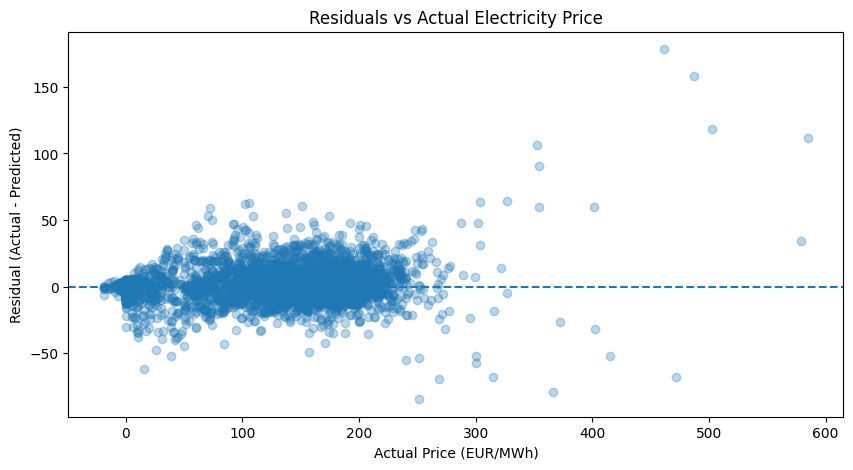

In [ ]:
plt.figure(figsize=(10, 5))
plt.scatter(y_test_common, residuals, alpha=0.3)
plt.axhline(0, linestyle="--")
plt.xlabel("Actual Price (EUR/MWh)")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residuals vs Actual Electricity Price")
plt.show()

In [ ]:
residual_lag = residuals.shift(1)

print(residuals.corr(residual_lag))

0.060279088201700935
